<a href="https://www.kaggle.com/code/lalit7881/fifa-world-cup-2026-player-performance-100?scriptVersionId=327325171" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/rauffauzanrambe/fifa-world-cup-2026-player-performance-dataset/fifa_world_cup_2026_player_performance.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/rauffauzanrambe/fifa-world-cup-2026-player-performance-dataset/fifa_world_cup_2026_player_performance.csv")

In [3]:
df.head()

,player_id,player_name,age,nationality,team,jersey_number,position,height_cm,weight_kg,preferred_foot,...,possession_impact,pressure_resistance,creativity_score,consistency_score,clutch_performance_score,total_goals_tournament,total_assists_tournament,total_minutes_tournament,player_of_match_awards,tournament_rating
0,P00055,Rodri Fati,26,Spanish,Spain,3,Goalkeeper,195,75,Left,...,1.1,44.2,55.9,42.0,51.8,0,0,242,0,5.8
1,P00070,Ansu Le Normand,19,Spanish,Spain,18,Midfielder,178,75,Right,...,3.5,38.2,43.7,31.1,52.7,0,3,342,0,5.5
2,P00066,Gavi Ramos,18,Spanish,Spain,14,Midfielder,177,72,Left,...,15.3,99.0,99.0,83.4,54.8,1,1,245,0,8.4
3,P00073,Pedro Cubarsi,20,Spanish,Spain,21,Forward,182,74,Right,...,1.2,19.8,42.3,40.9,78.5,5,3,422,0,6.7
4,P00059,Alvaro Oyarzabal,23,Spanish,Spain,7,Defender,191,81,Left,...,6.2,44.1,33.5,60.0,56.6,0,0,440,0,5.7


In [4]:
df.tail()

,player_id,player_name,age,nationality,team,jersey_number,position,height_cm,weight_kg,preferred_foot,...,possession_impact,pressure_resistance,creativity_score,consistency_score,clutch_performance_score,total_goals_tournament,total_assists_tournament,total_minutes_tournament,player_of_match_awards,tournament_rating
54595,P00996,Amir Younis,28,Iraqi,Iraq,8,Defender,177,73,Right,...,0.0,41.9,27.7,31.3,40.5,1,0,97,0,0.0
54596,P01006,Safaa Al-Khafaji,20,Iraqi,Iraq,18,Midfielder,176,72,Right,...,0.0,64.2,53.1,64.8,64.3,2,0,206,0,0.0
54597,P01008,Ahmed Hussein,26,Iraqi,Iraq,20,Midfielder,173,77,Left,...,0.0,75.4,55.0,65.0,64.5,1,1,359,0,0.0
54598,P00991,Ibrahim Mhawi,30,Iraqi,Iraq,3,Goalkeeper,190,81,Right,...,0.0,96.3,39.6,99.0,99.0,0,0,342,0,0.0
54599,P00989,Mohannad Hussein,27,Iraqi,Iraq,1,Goalkeeper,187,73,Right,...,0.0,99.0,34.1,99.0,99.0,0,0,286,0,0.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54600 entries, 0 to 54599
Data columns (total 75 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   player_id                 54600 non-null  object 
 1   player_name               54600 non-null  object 
 2   age                       54600 non-null  int64  
 3   nationality               54600 non-null  object 
 4   team                      54600 non-null  object 
 5   jersey_number             54600 non-null  int64  
 6   position                  54600 non-null  object 
 7   height_cm                 54600 non-null  int64  
 8   weight_kg                 54600 non-null  int64  
 9   preferred_foot            54600 non-null  object 
 10  club_name                 54600 non-null  object 
 11  market_value_eur          54600 non-null  int64  
 12  match_id                  54600 non-null  object 
 13  match_date                54600 non-null  object 
 14  stadiu

In [6]:
df.describe()

,age,jersey_number,height_cm,weight_kg,market_value_eur,goals_team,goals_opponent,minutes_played,goals,assists,...,possession_impact,pressure_resistance,creativity_score,consistency_score,clutch_performance_score,total_goals_tournament,total_assists_tournament,total_minutes_tournament,player_of_match_awards,tournament_rating
count,54600.000000,54600.000000,54600.000000,54600.000000,5.460000e+04,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,...,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000
mean,26.296484,13.500000,181.654341,75.754853,2.008445e+07,1.330476,1.330476,36.199817,0.055385,0.052363,...,2.850165,60.318379,46.135778,63.750396,55.572154,0.643993,0.607601,272.300311,0.030659,3.634046
std,4.067519,7.500069,6.277792,3.951481,2.718866e+07,1.147814,1.147814,36.419755,0.251900,0.239021,...,4.228436,20.234988,22.424337,19.860028,13.661343,1.093781,0.931527,116.806184,0.206520,3.163411
min,17.000000,1.000000,163.000000,65.000000,5.288220e+05,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,15.000000,5.000000,25.000000,15.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,23.000000,7.000000,177.000000,73.000000,4.444778e+06,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,43.700000,29.800000,46.500000,46.400000,0.000000,0.000000,184.000000,0.000000,0.000000
50%,26.000000,13.500000,182.000000,76.000000,1.027111e+07,1.000000,1.000000,24.000000,0.000000,0.000000,...,1.100000,57.000000,40.500000,61.100000,55.000000,0.000000,0.000000,268.000000,0.000000,5.400000
75%,29.000000,20.000000,186.000000,78.000000,2.342013e+07,2.000000,2.000000,75.000000,0.000000,0.000000,...,4.000000,75.100000,59.000000,78.900000,63.900000,1.000000,1.000000,359.000000,0.000000,6.400000
max,39.000000,26.000000,200.000000,87.000000,2.000000e+08,7.000000,7.000000,90.000000,4.000000,3.000000,...,37.000000,99.000000,99.000000,99.000000,99.000000,10.000000,8.000000,615.000000,4.000000,9.500000


In [7]:
df.isnull()

,player_id,player_name,age,nationality,team,jersey_number,position,height_cm,weight_kg,preferred_foot,...,possession_impact,pressure_resistance,creativity_score,consistency_score,clutch_performance_score,total_goals_tournament,total_assists_tournament,total_minutes_tournament,player_of_match_awards,tournament_rating
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54595,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
54596,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
54597,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
54598,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [8]:
df.isnull().sum()

player_id                   0
player_name                 0
age                         0
nationality                 0
team                        0
                           ..
total_goals_tournament      0
total_assists_tournament    0
total_minutes_tournament    0
player_of_match_awards      0
tournament_rating           0
Length: 75, dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.dtypes


player_id                    object
player_name                  object
age                           int64
nationality                  object
team                         object
                             ...   
total_goals_tournament        int64
total_assists_tournament      int64
total_minutes_tournament      int64
player_of_match_awards        int64
tournament_rating           float64
Length: 75, dtype: object

In [11]:
df.shape


(54600, 75)

In [12]:
df.columns

Index(['player_id', 'player_name', 'age', 'nationality', 'team',
       'jersey_number', 'position', 'height_cm', 'weight_kg', 'preferred_foot',
       'club_name', 'market_value_eur', 'match_id', 'match_date', 'stadium',
       'city', 'opponent_team', 'tournament_stage', 'match_result',
       'goals_team', 'goals_opponent', 'minutes_played', 'goals', 'assists',
       'shots', 'shots_on_target', 'expected_goals_xg', 'expected_assists_xa',
       'key_passes', 'successful_passes', 'total_passes', 'pass_accuracy',
       'dribbles_attempted', 'successful_dribbles', 'crosses',
       'successful_crosses', 'tackles', 'interceptions', 'clearances',
       'blocks', 'aerial_duels_won', 'aerial_duels_lost', 'recoveries',
       'defensive_actions', 'fouls_committed', 'fouls_suffered',
       'yellow_cards', 'red_cards', 'offsides', 'saves', 'save_percentage',
       'punches', 'clean_sheet', 'goals_conceded', 'penalty_saves',
       'distance_covered_km', 'sprint_distance_km', 'top_speed_k

In [13]:
df.nunique()

player_id                   1248
player_name                 1245
age                           23
nationality                   48
team                          48
                            ... 
total_goals_tournament        11
total_assists_tournament       9
total_minutes_tournament     586
player_of_match_awards         5
tournament_rating             63
Length: 75, dtype: int64

## EDA

In [14]:
print("Dataset Shape:", df.shape)
print(df.info())
print(df.describe())


Dataset Shape: (54600, 75)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54600 entries, 0 to 54599
Data columns (total 75 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   player_id                 54600 non-null  object 
 1   player_name               54600 non-null  object 
 2   age                       54600 non-null  int64  
 3   nationality               54600 non-null  object 
 4   team                      54600 non-null  object 
 5   jersey_number             54600 non-null  int64  
 6   position                  54600 non-null  object 
 7   height_cm                 54600 non-null  int64  
 8   weight_kg                 54600 non-null  int64  
 9   preferred_foot            54600 non-null  object 
 10  club_name                 54600 non-null  object 
 11  market_value_eur          54600 non-null  int64  
 12  match_id                  54600 non-null  object 
 13  match_date                54600 no

In [15]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12,6)


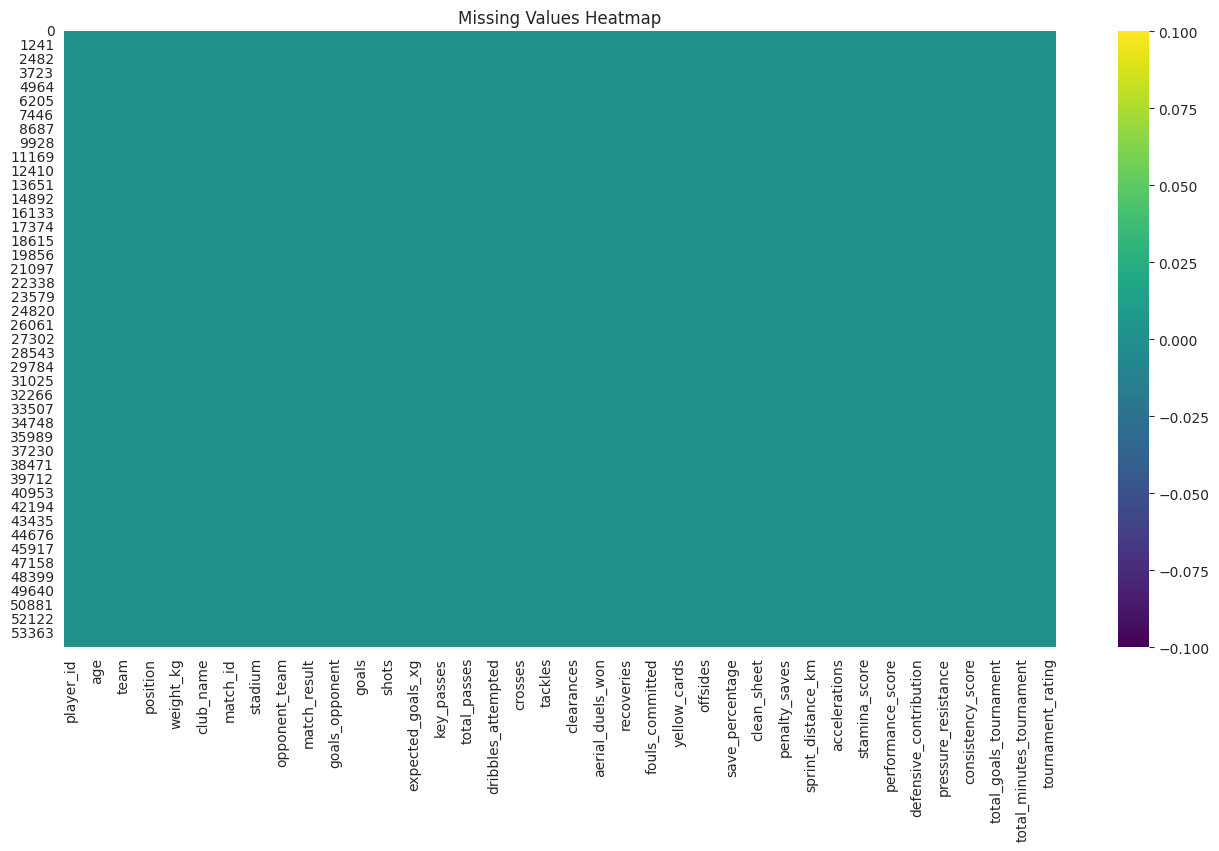

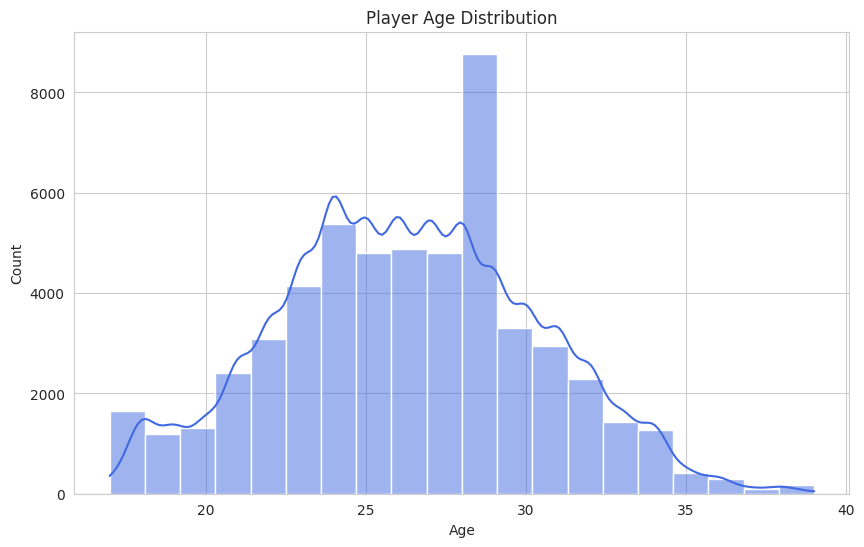

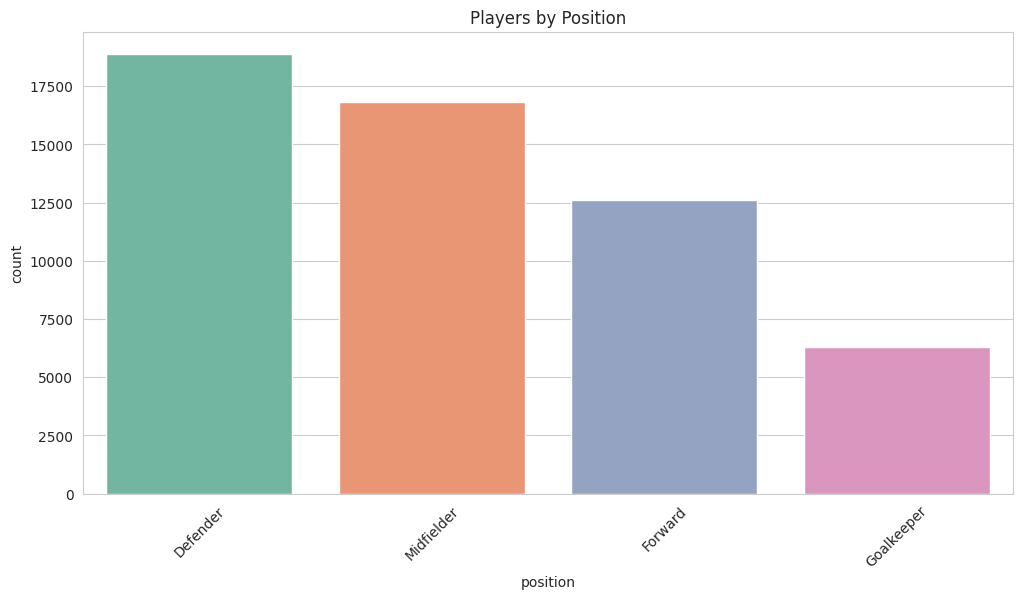

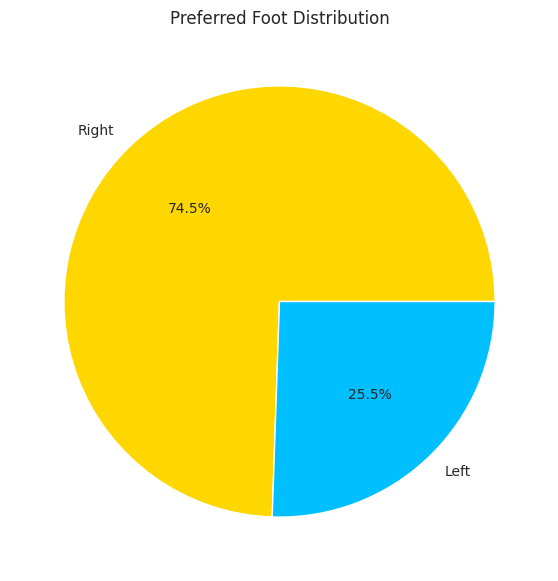

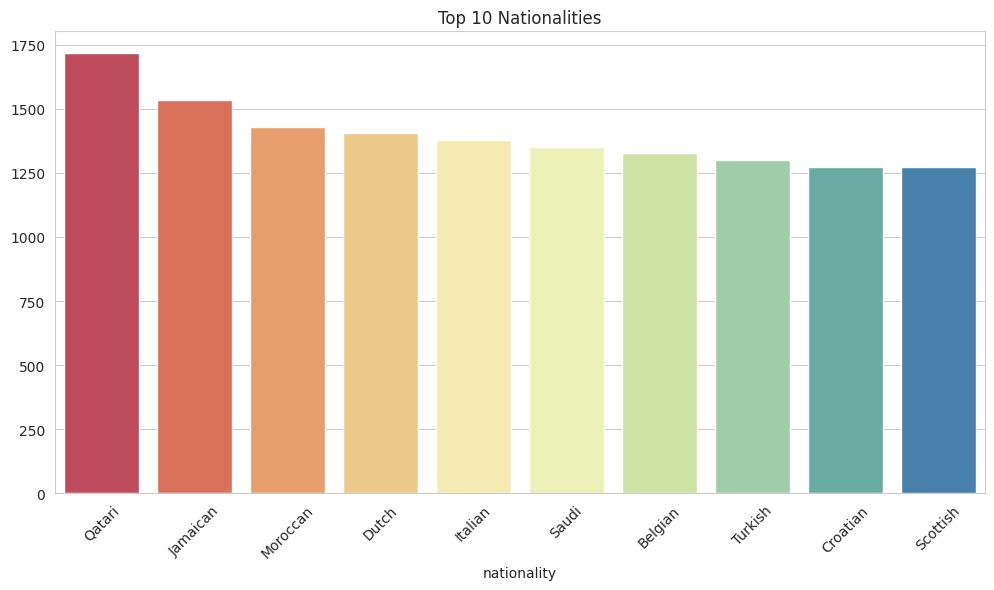

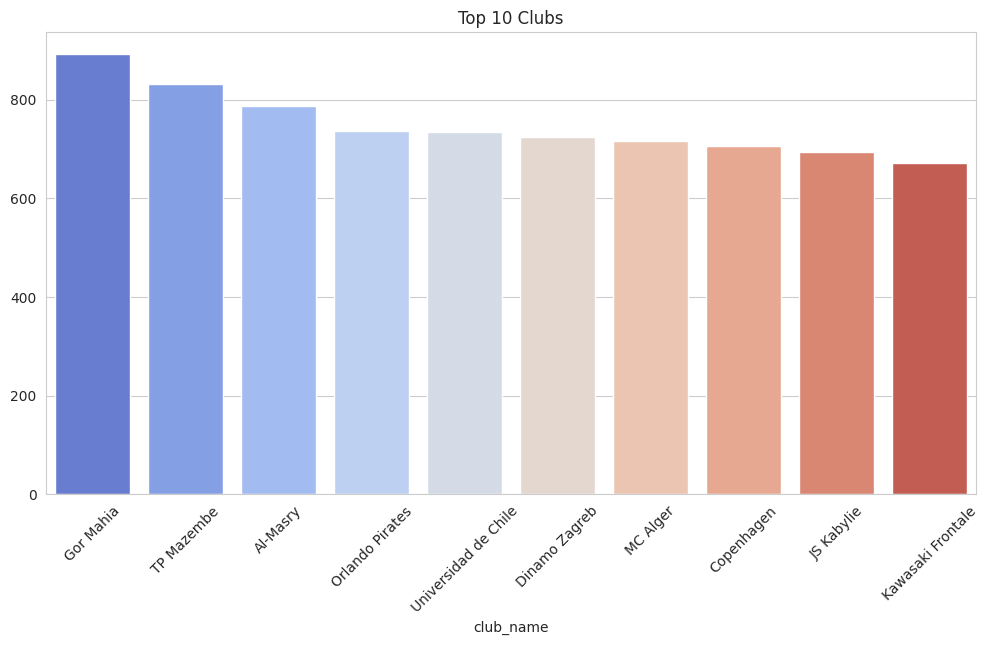

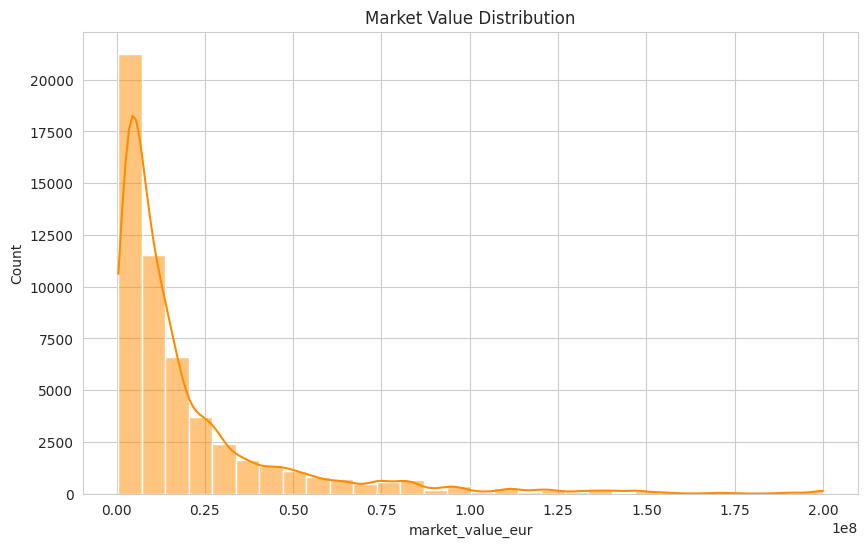

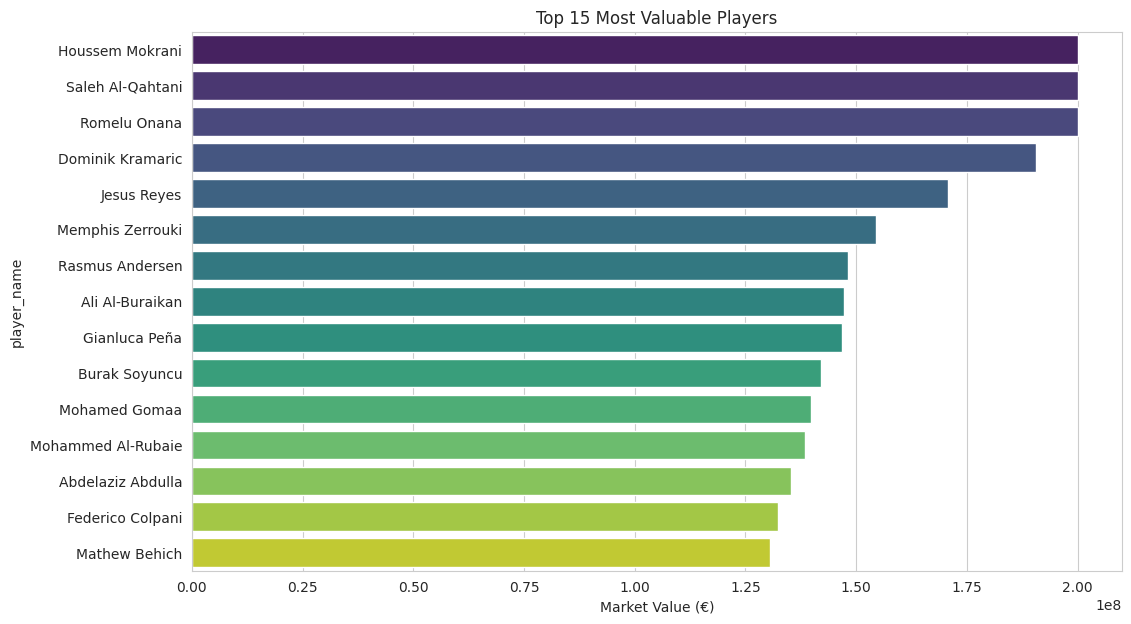

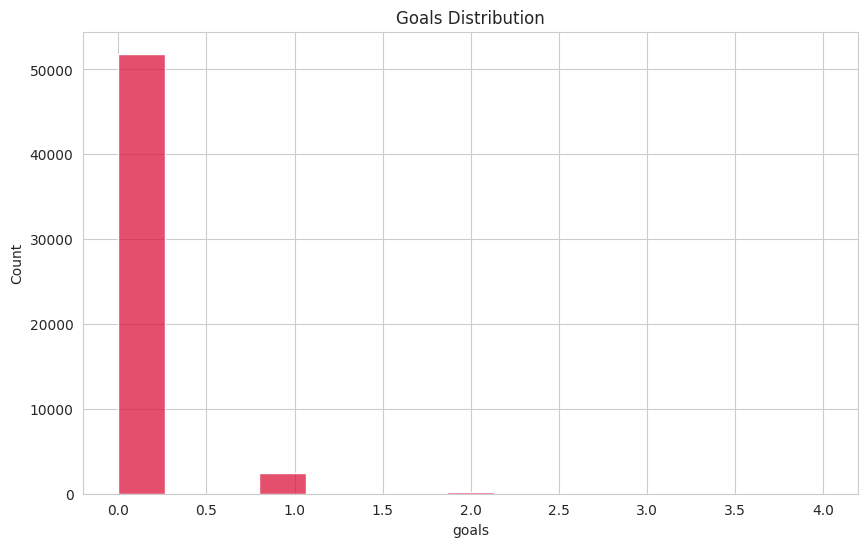

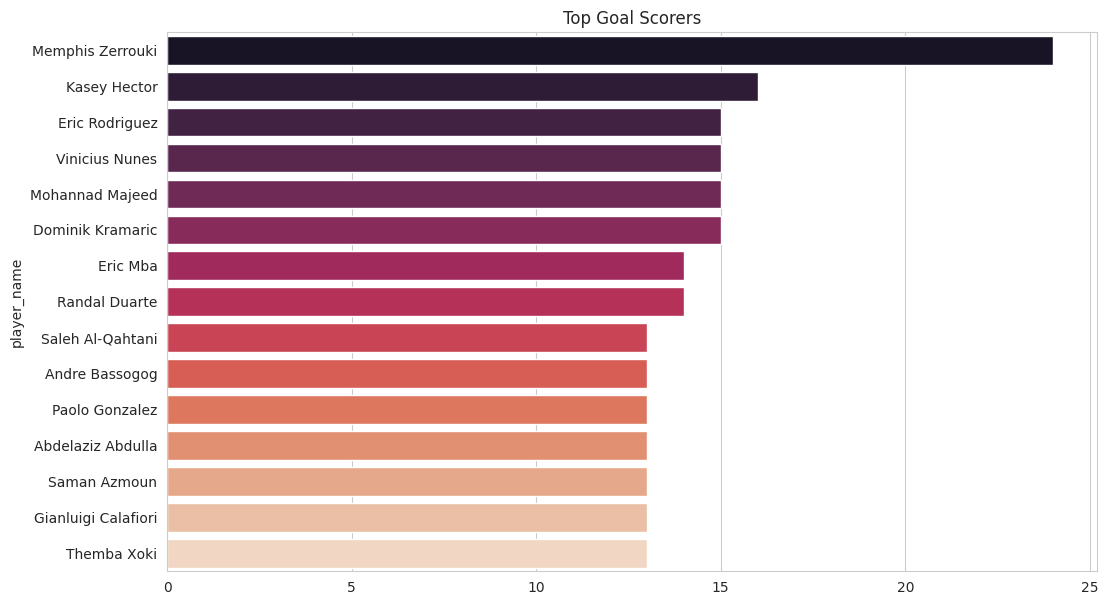

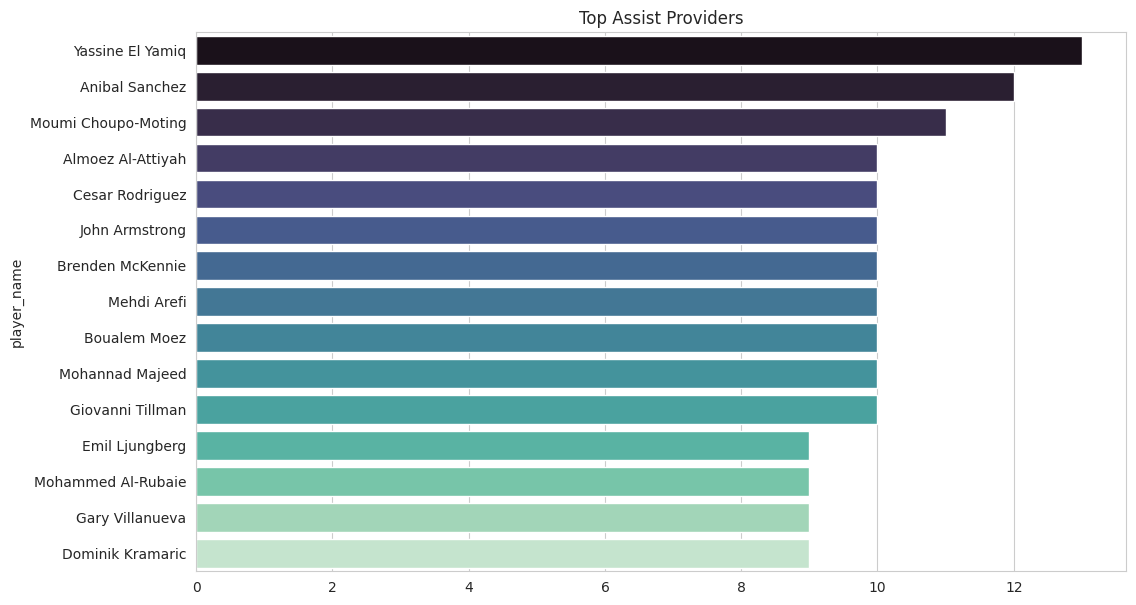

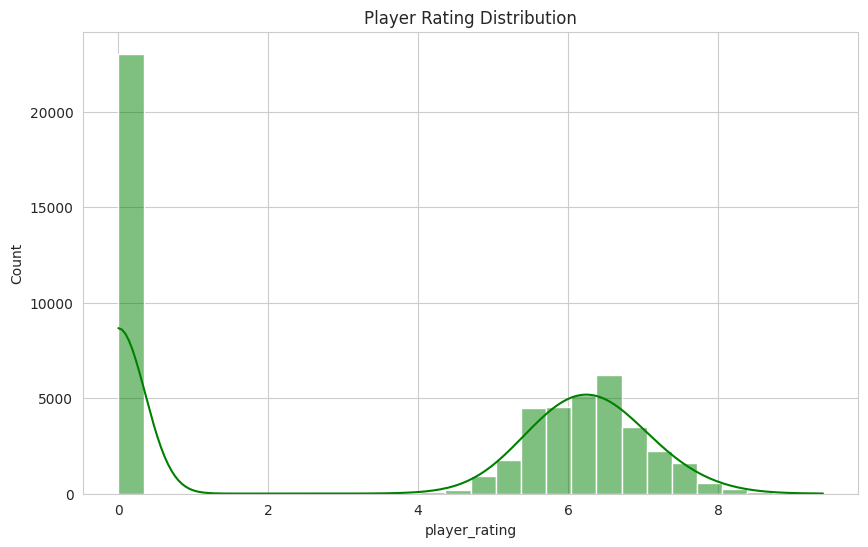

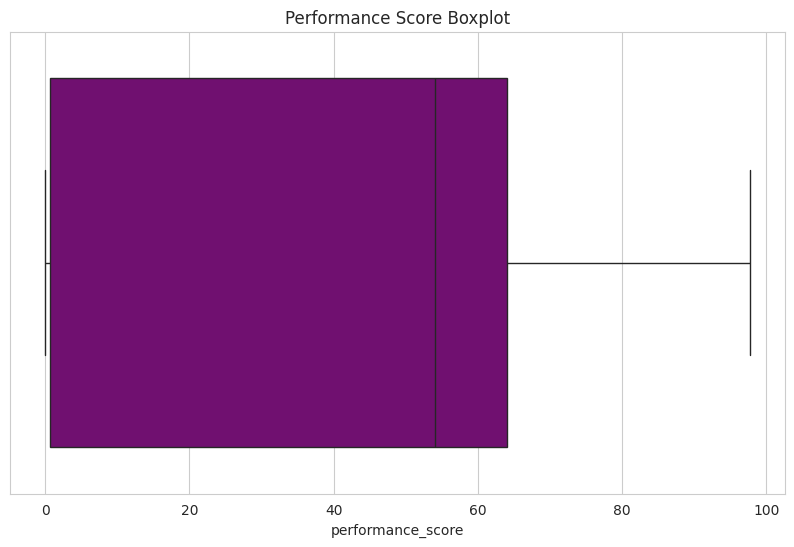

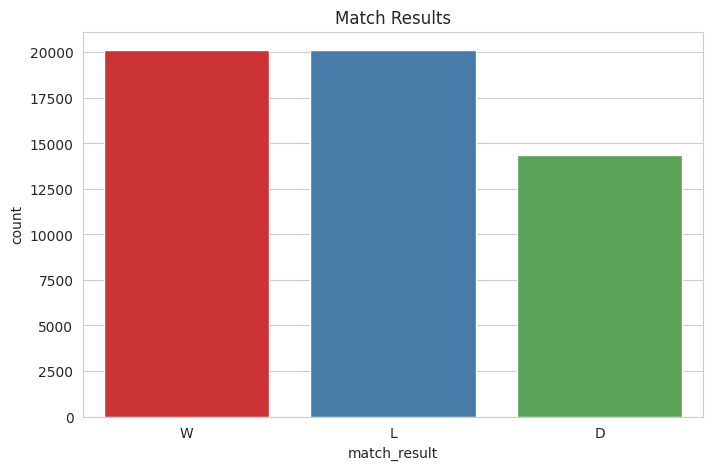

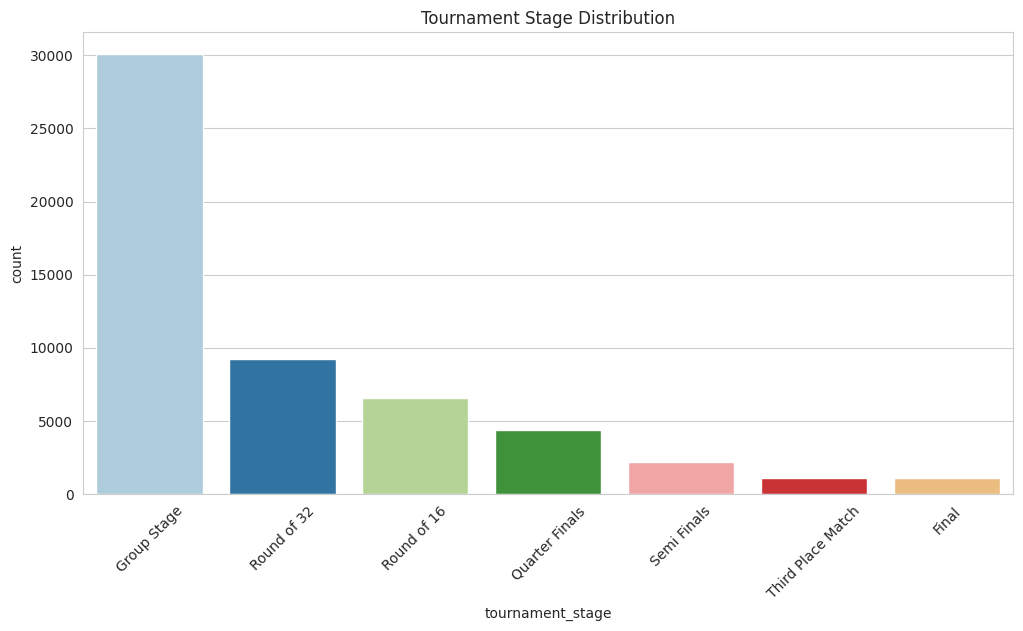

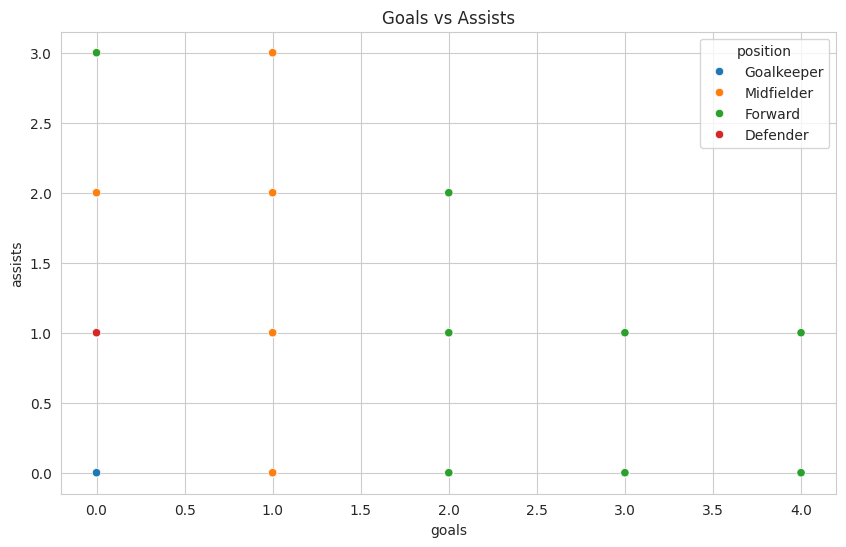

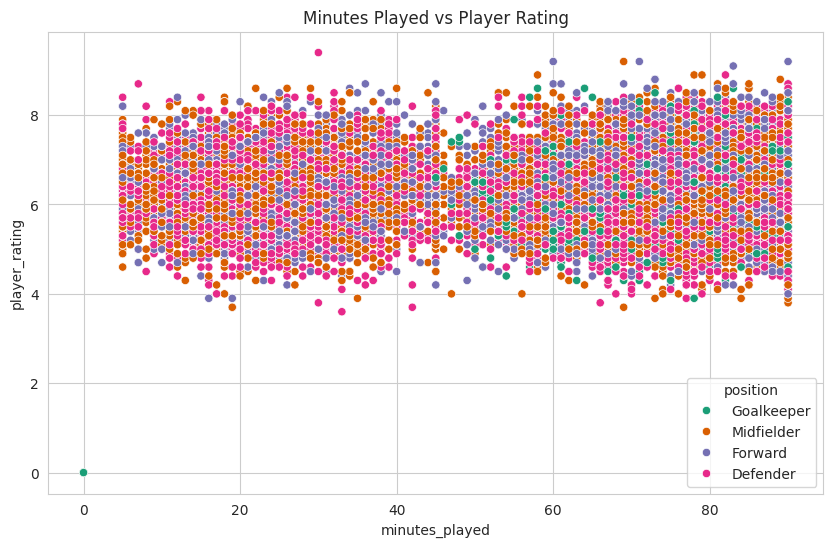

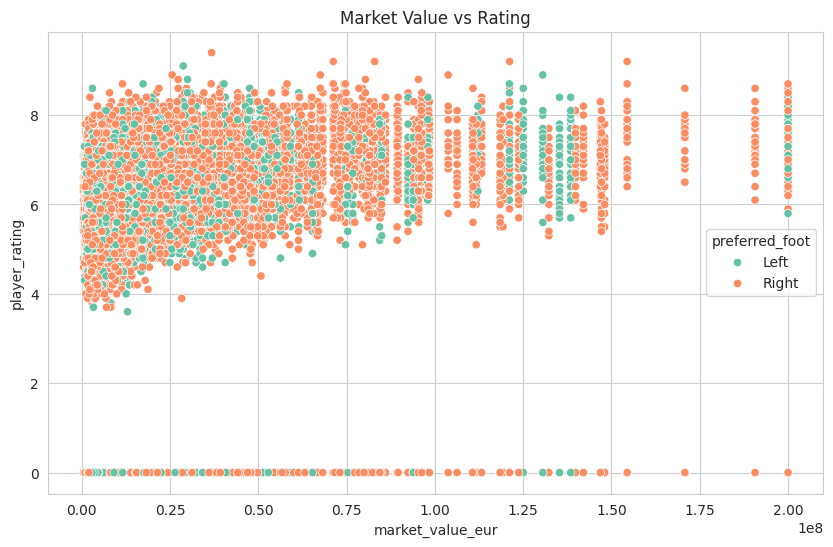

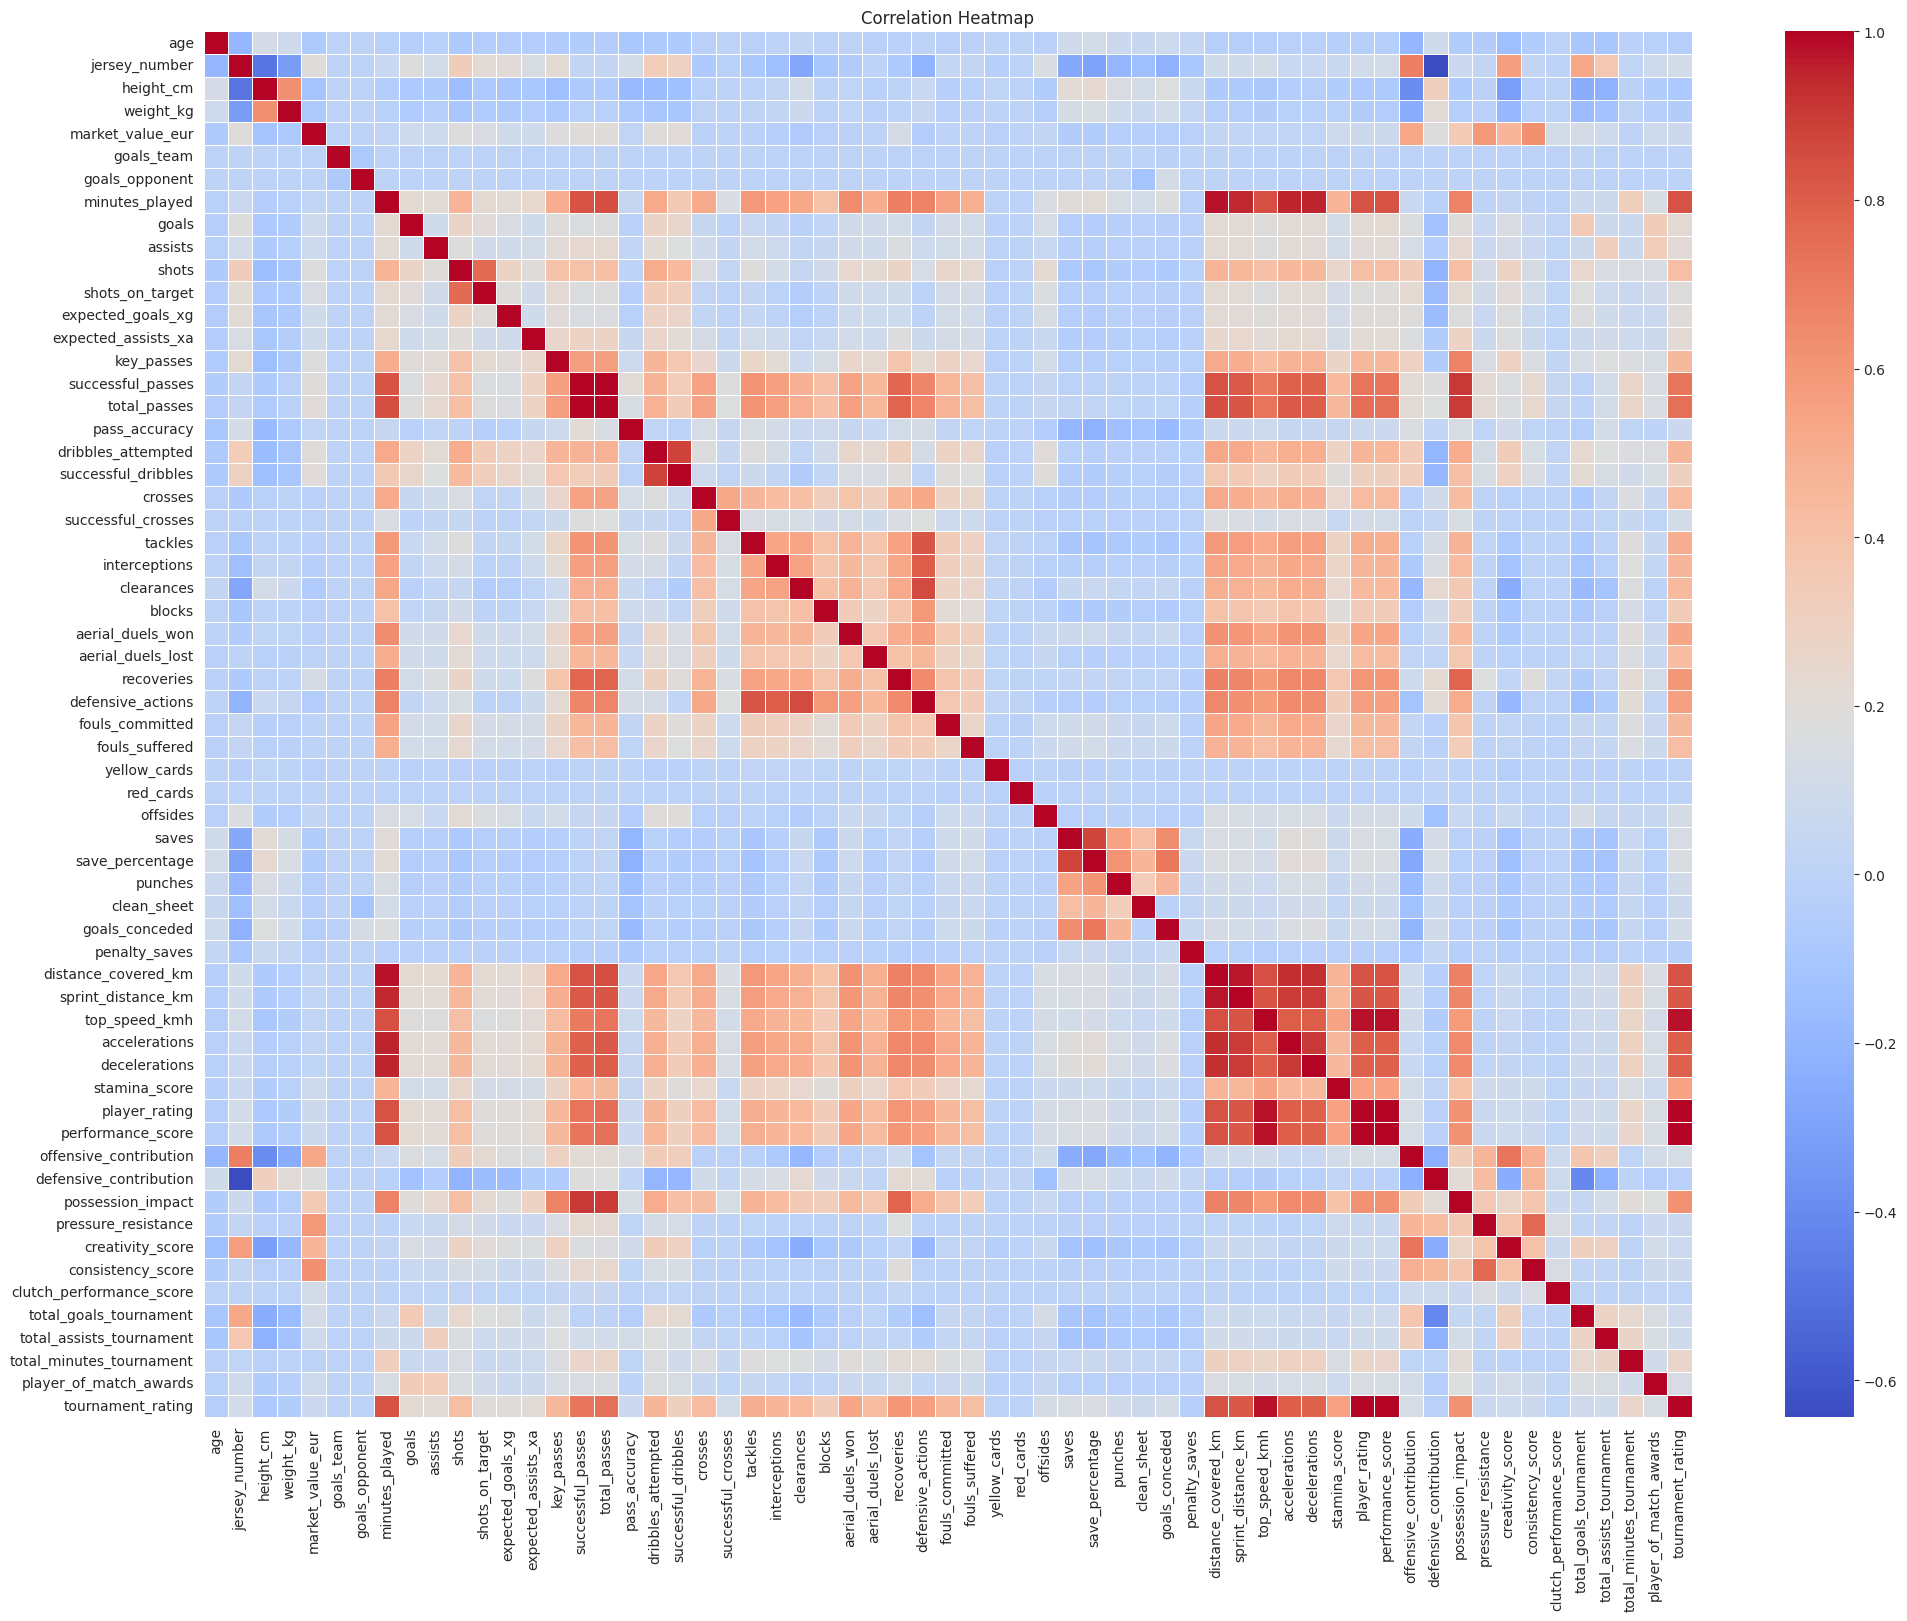

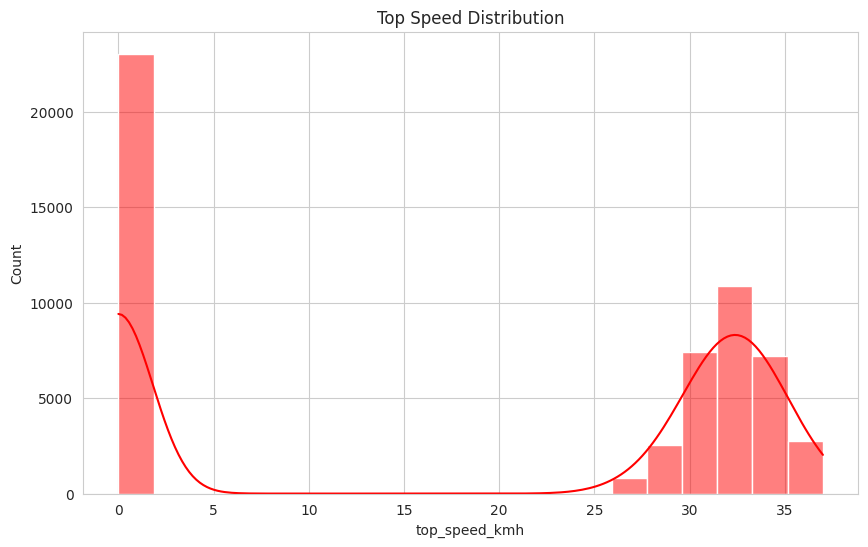

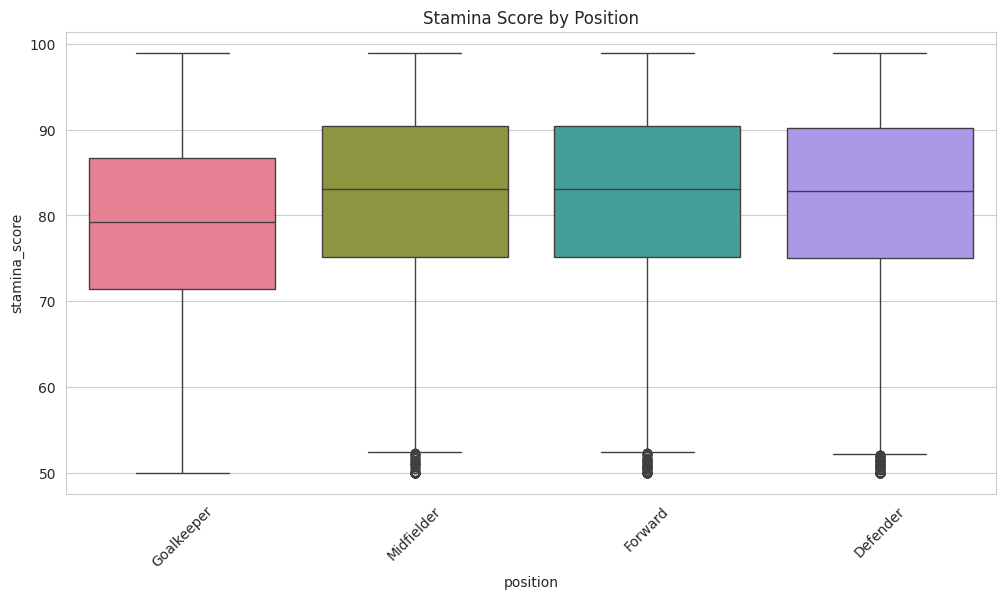

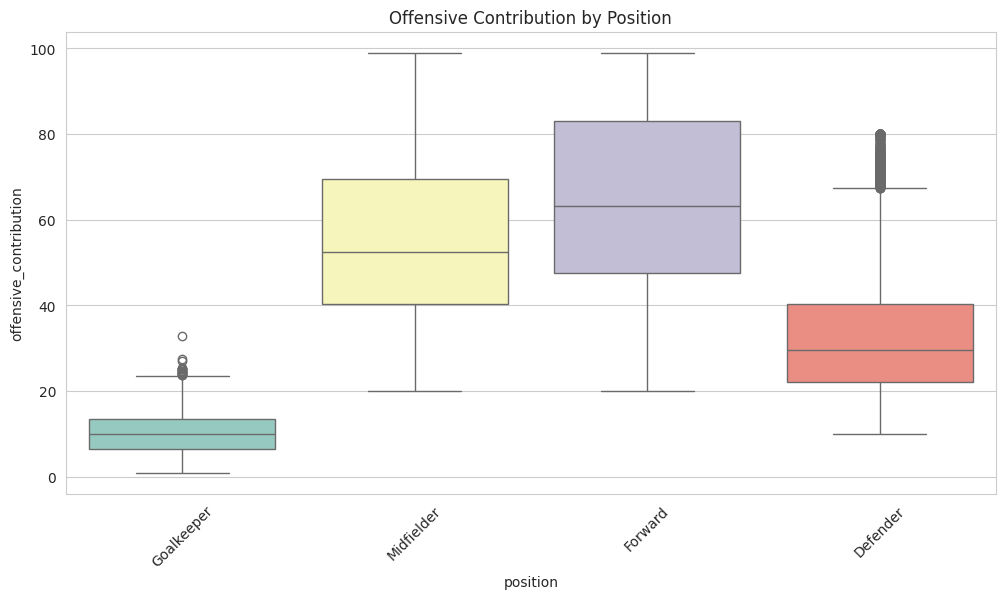

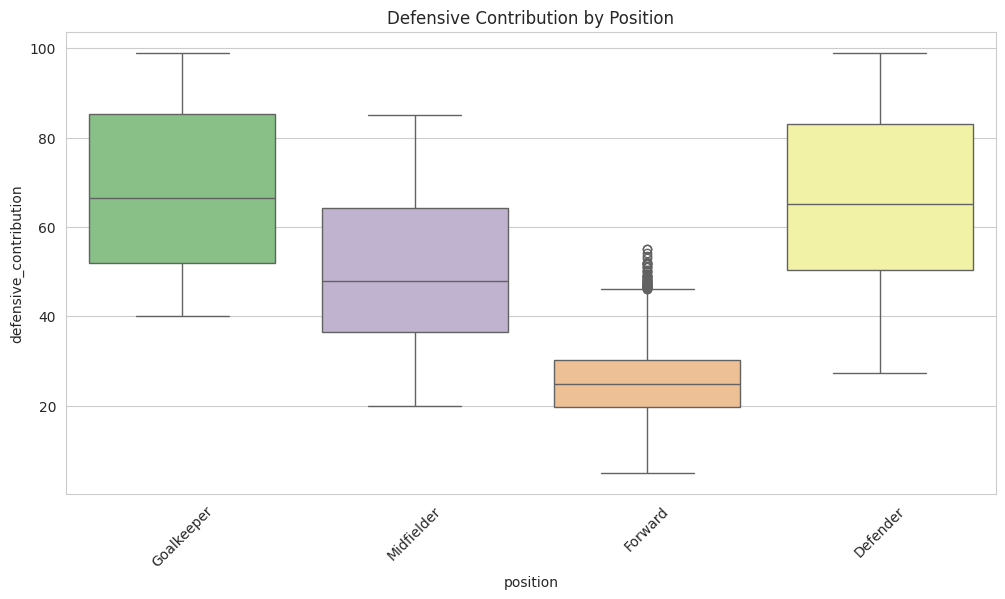

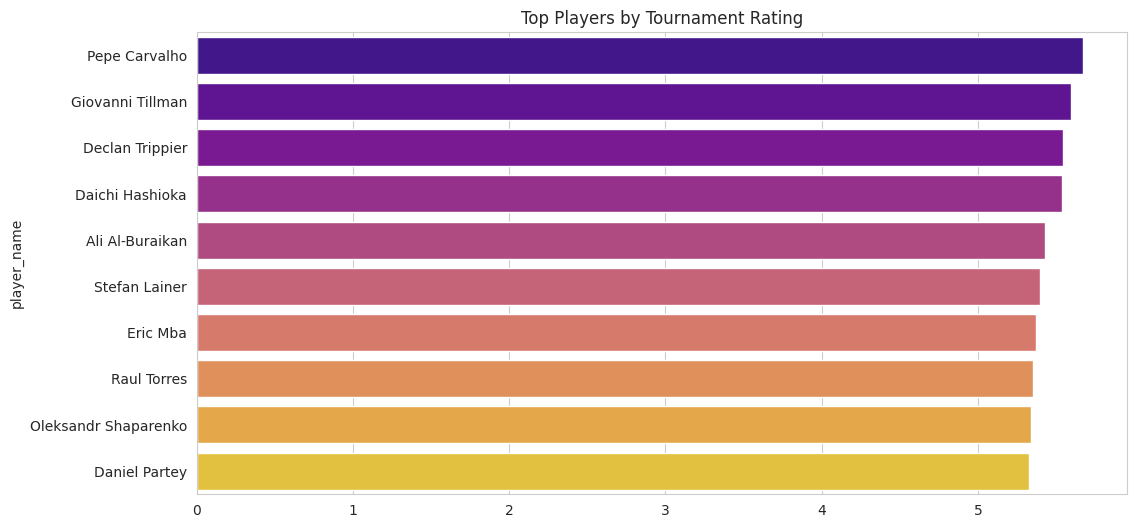

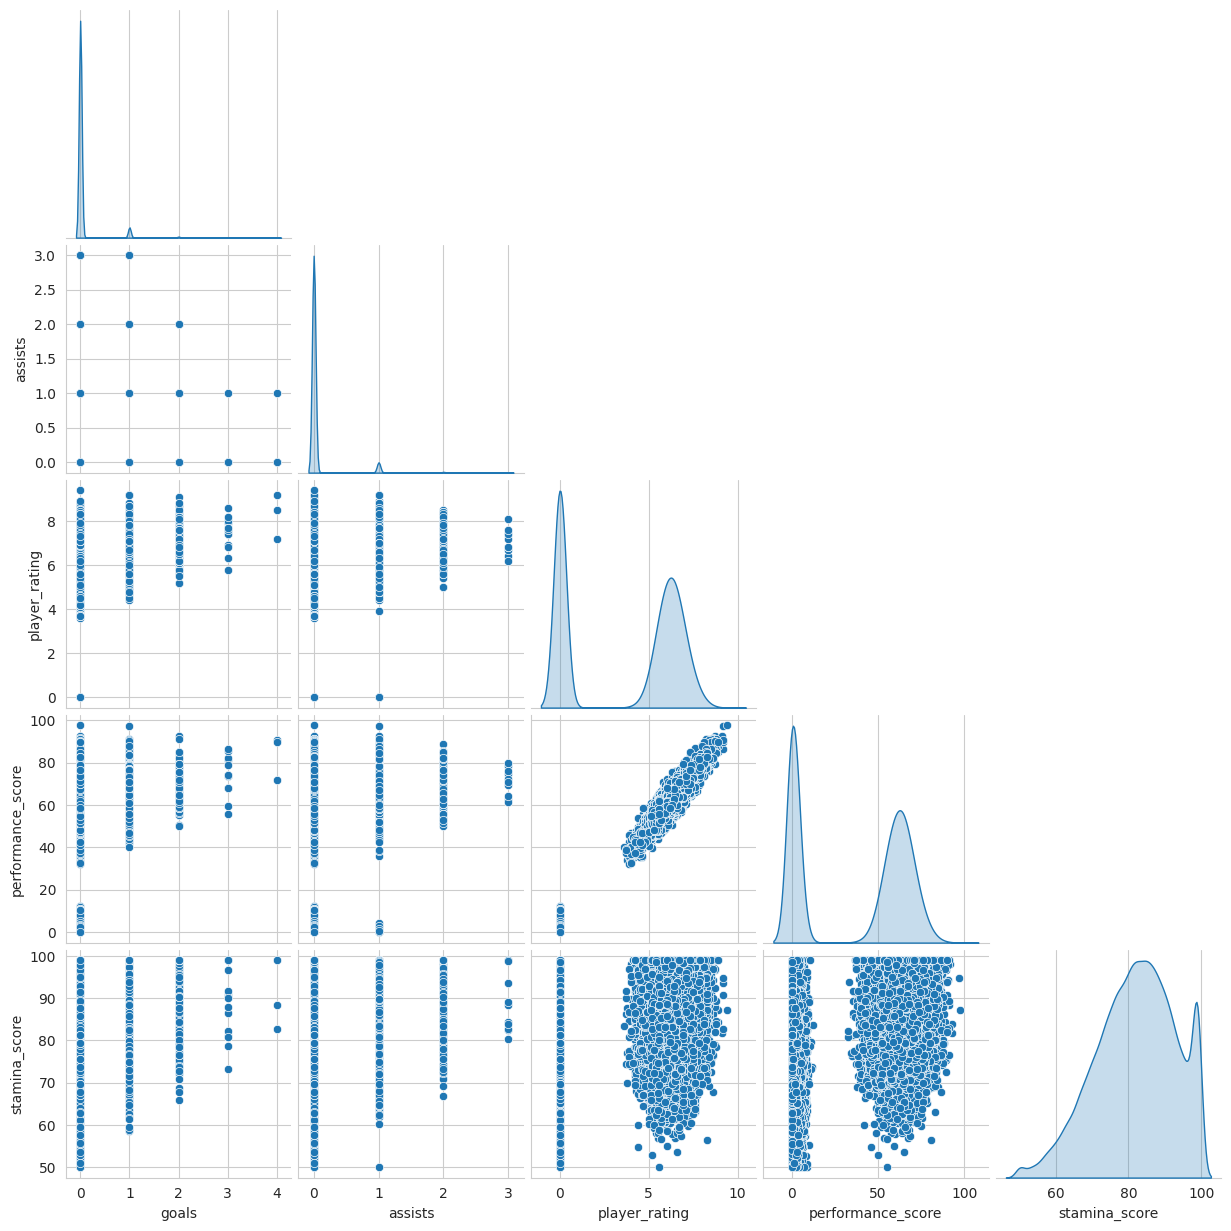

Football Dataset EDA Completed Successfully!


In [16]:
# ============================================================
# 1. Missing Values Heatmap
# ============================================================
plt.figure(figsize=(16,8))
sns.heatmap(df.isnull(),
            cbar=True,
            cmap='viridis')
plt.title("Missing Values Heatmap")
plt.show()

# ============================================================
# 2. Age Distribution
# ============================================================
plt.figure(figsize=(10,6))
sns.histplot(df['age'],
             bins=20,
             kde=True,
             color='royalblue')
plt.title("Player Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

# ============================================================
# 3. Position Distribution
# ============================================================
plt.figure(figsize=(12,6))
sns.countplot(
    data=df,
    x='position',
    palette='Set2',
    order=df['position'].value_counts().index
)
plt.title("Players by Position")
plt.xticks(rotation=45)
plt.show()

# ============================================================
# 4. Preferred Foot Analysis
# ============================================================
plt.figure(figsize=(7,7))
df['preferred_foot'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=['gold','deepskyblue']
)
plt.title("Preferred Foot Distribution")
plt.ylabel("")
plt.show()

# ============================================================
# 5. Top 10 Nationalities
# ============================================================
plt.figure(figsize=(12,6))
top_nations = df['nationality'].value_counts().head(10)

sns.barplot(
    x=top_nations.index,
    y=top_nations.values,
    palette='Spectral'
)
plt.title("Top 10 Nationalities")
plt.xticks(rotation=45)
plt.show()

# ============================================================
# 6. Top 10 Clubs by Players
# ============================================================
plt.figure(figsize=(12,6))
top_clubs = df['club_name'].value_counts().head(10)

sns.barplot(
    x=top_clubs.index,
    y=top_clubs.values,
    palette='coolwarm'
)
plt.title("Top 10 Clubs")
plt.xticks(rotation=45)
plt.show()

# ============================================================
# 7. Market Value Distribution
# ============================================================
plt.figure(figsize=(10,6))
sns.histplot(df['market_value_eur'],
             bins=30,
             color='darkorange',
             kde=True)
plt.title("Market Value Distribution")
plt.show()

# ============================================================
# 8. Top 15 Most Valuable Players
# ============================================================
top_players = df.groupby('player_name')['market_value_eur']\
                .max()\
                .sort_values(ascending=False)\
                .head(15)

plt.figure(figsize=(12,7))
sns.barplot(
    x=top_players.values,
    y=top_players.index,
    palette='viridis'
)
plt.title("Top 15 Most Valuable Players")
plt.xlabel("Market Value (€)")
plt.show()

# ============================================================
# 9. Goals Distribution
# ============================================================
plt.figure(figsize=(10,6))
sns.histplot(df['goals'],
             bins=15,
             color='crimson')
plt.title("Goals Distribution")
plt.show()

# ============================================================
# 10. Top Goal Scorers
# ============================================================
top_scorers = df.groupby('player_name')['goals']\
                .sum()\
                .sort_values(ascending=False)\
                .head(15)

plt.figure(figsize=(12,7))
sns.barplot(
    x=top_scorers.values,
    y=top_scorers.index,
    palette='rocket'
)
plt.title("Top Goal Scorers")
plt.show()

# ============================================================
# 11. Top Assist Providers
# ============================================================
top_assists = df.groupby('player_name')['assists']\
                .sum()\
                .sort_values(ascending=False)\
                .head(15)

plt.figure(figsize=(12,7))
sns.barplot(
    x=top_assists.values,
    y=top_assists.index,
    palette='mako'
)
plt.title("Top Assist Providers")
plt.show()

# ============================================================
# 12. Player Rating Distribution
# ============================================================
plt.figure(figsize=(10,6))
sns.histplot(
    df['player_rating'],
    kde=True,
    color='green'
)
plt.title("Player Rating Distribution")
plt.show()

# ============================================================
# 13. Performance Score Distribution
# ============================================================
plt.figure(figsize=(10,6))
sns.boxplot(
    x=df['performance_score'],
    color='purple'
)
plt.title("Performance Score Boxplot")
plt.show()

# ============================================================
# 14. Match Results
# ============================================================
plt.figure(figsize=(8,5))
sns.countplot(
    data=df,
    x='match_result',
    palette='Set1'
)
plt.title("Match Results")
plt.show()

# ============================================================
# 15. Tournament Stage Analysis
# ============================================================
plt.figure(figsize=(12,6))
sns.countplot(
    data=df,
    x='tournament_stage',
    palette='Paired'
)
plt.title("Tournament Stage Distribution")
plt.xticks(rotation=45)
plt.show()

# ============================================================
# 16. Goals vs Assists
# ============================================================
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df,
    x='goals',
    y='assists',
    hue='position',
    palette='tab10'
)
plt.title("Goals vs Assists")
plt.show()

# ============================================================
# 17. Minutes Played vs Rating
# ============================================================
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df,
    x='minutes_played',
    y='player_rating',
    hue='position',
    palette='Dark2'
)
plt.title("Minutes Played vs Player Rating")
plt.show()

# ============================================================
# 18. Market Value vs Rating
# ============================================================
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df,
    x='market_value_eur',
    y='player_rating',
    hue='preferred_foot',
    palette='Set2'
)
plt.title("Market Value vs Rating")
plt.show()

# ============================================================
# 19. Correlation Heatmap
# ============================================================
numeric_cols = df.select_dtypes(include=np.number)

plt.figure(figsize=(24,18))
corr = numeric_cols.corr()

sns.heatmap(
    corr,
    cmap='coolwarm',
    annot=False,
    linewidths=0.5
)
plt.title("Correlation Heatmap")
plt.show()

# ============================================================
# 20. Top Speed Distribution
# ============================================================
plt.figure(figsize=(10,6))
sns.histplot(
    df['top_speed_kmh'],
    bins=20,
    color='red',
    kde=True
)
plt.title("Top Speed Distribution")
plt.show()

# ============================================================
# 21. Stamina Score by Position
# ============================================================
plt.figure(figsize=(12,6))
sns.boxplot(
    data=df,
    x='position',
    y='stamina_score',
    palette='husl'
)
plt.title("Stamina Score by Position")
plt.xticks(rotation=45)
plt.show()

# ============================================================
# 22. Offensive Contribution by Position
# ============================================================
plt.figure(figsize=(12,6))
sns.boxplot(
    data=df,
    x='position',
    y='offensive_contribution',
    palette='Set3'
)
plt.title("Offensive Contribution by Position")
plt.xticks(rotation=45)
plt.show()

# ============================================================
# 23. Defensive Contribution by Position
# ============================================================
plt.figure(figsize=(12,6))
sns.boxplot(
    data=df,
    x='position',
    y='defensive_contribution',
    palette='Accent'
)
plt.title("Defensive Contribution by Position")
plt.xticks(rotation=45)
plt.show()

# ============================================================
# 24. Top 10 Players by Tournament Rating
# ============================================================
top_rating = df.groupby('player_name')['tournament_rating']\
               .mean()\
               .sort_values(ascending=False)\
               .head(10)

plt.figure(figsize=(12,6))
sns.barplot(
    x=top_rating.values,
    y=top_rating.index,
    palette='plasma'
)
plt.title("Top Players by Tournament Rating")
plt.show()

# ============================================================
# 25. Pairplot of Important Features
# ============================================================
important_features = [
    'goals',
    'assists',
    'player_rating',
    'performance_score',
    'stamina_score'
]

sns.pairplot(
    df[important_features].dropna(),
    corner=True,
    diag_kind='kde'
)
plt.show()

print("Football Dataset EDA Completed Successfully!")

## Feature engineering

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, label_binarize

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)

from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

Shape: (54600, 75)

Target Classes:
{'D': 0, 'L': 1, 'W': 2}

Train Shape: (43680, 71)
Test Shape: (10920, 71)

Numeric Features: 61
Categorical Features: 10

Logistic Regression

Accuracy: 0.6425

Classification Report:
              precision    recall  f1-score   support

           D       0.41      0.31      0.35      2870
           L       0.76      0.79      0.77      4025
           W       0.65      0.73      0.69      4025

    accuracy                           0.64     10920
   macro avg       0.60      0.61      0.60     10920
weighted avg       0.63      0.64      0.63     10920



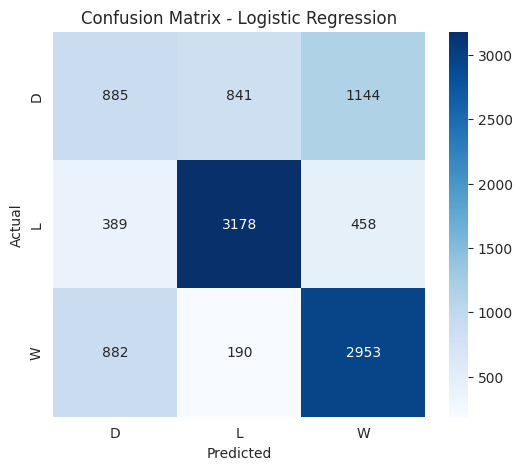


Decision Tree

Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

           D       1.00      1.00      1.00      2870
           L       1.00      1.00      1.00      4025
           W       1.00      1.00      1.00      4025

    accuracy                           1.00     10920
   macro avg       1.00      1.00      1.00     10920
weighted avg       1.00      1.00      1.00     10920



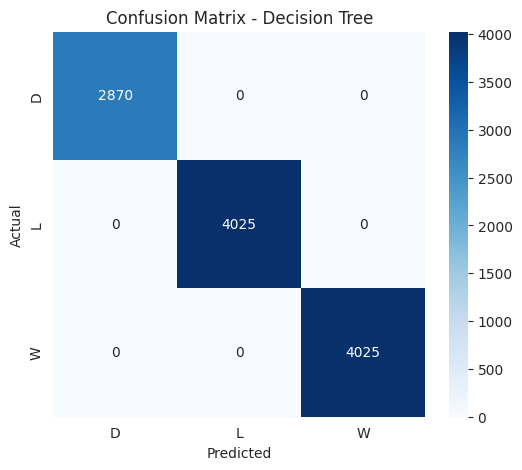


Random Forest

Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

           D       1.00      1.00      1.00      2870
           L       1.00      1.00      1.00      4025
           W       1.00      1.00      1.00      4025

    accuracy                           1.00     10920
   macro avg       1.00      1.00      1.00     10920
weighted avg       1.00      1.00      1.00     10920



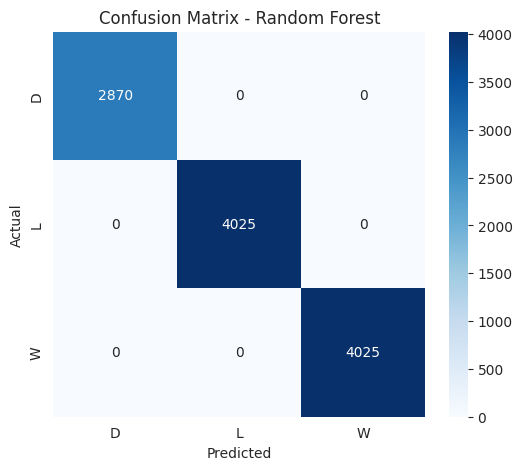


Gradient Boosting

Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

           D       1.00      1.00      1.00      2870
           L       1.00      1.00      1.00      4025
           W       1.00      1.00      1.00      4025

    accuracy                           1.00     10920
   macro avg       1.00      1.00      1.00     10920
weighted avg       1.00      1.00      1.00     10920



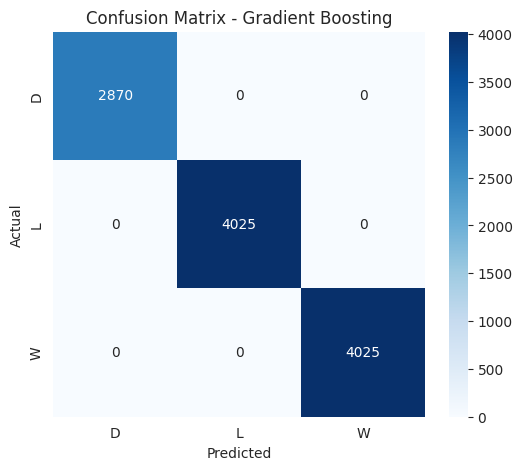


Model Comparison
                 Model  Accuracy
1        Decision Tree  1.000000
2        Random Forest  1.000000
3    Gradient Boosting  1.000000
0  Logistic Regression  0.642491


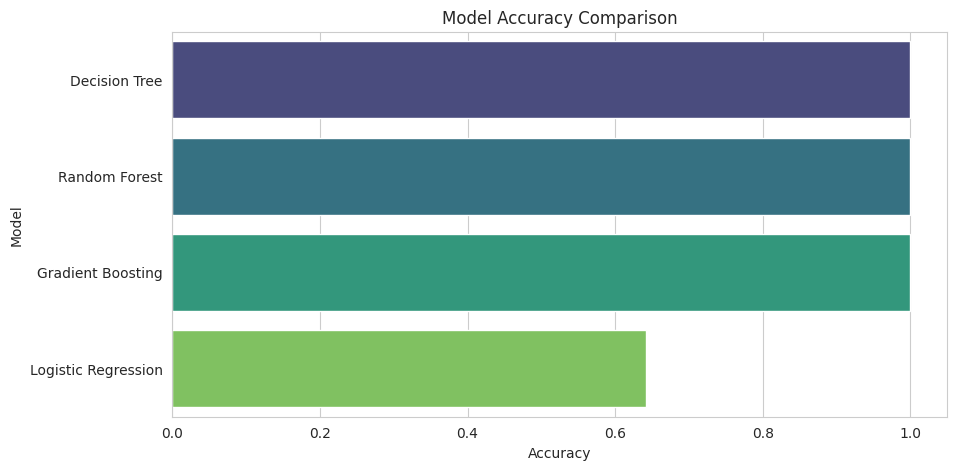


Best Model: Decision Tree


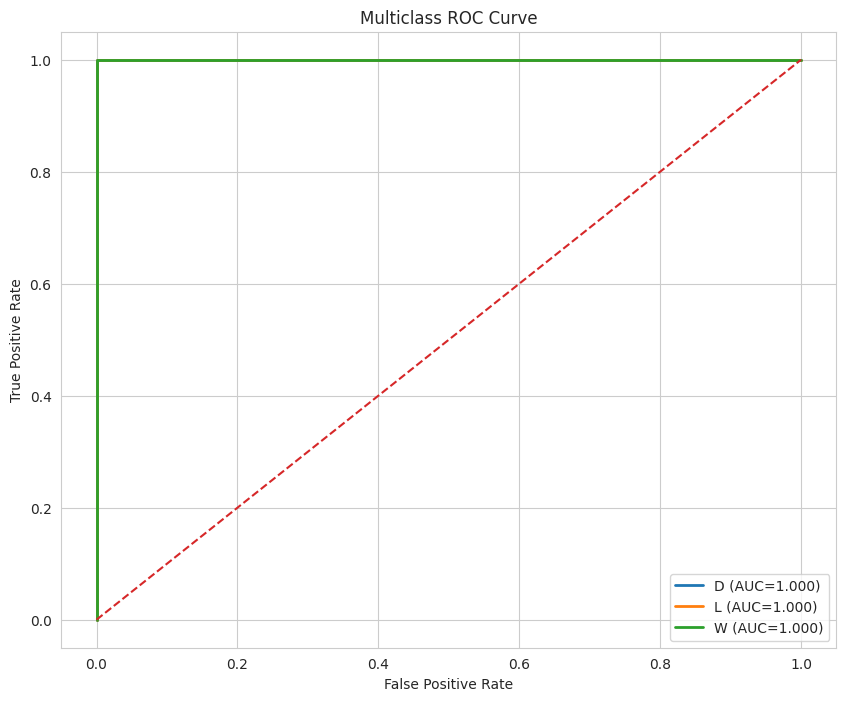

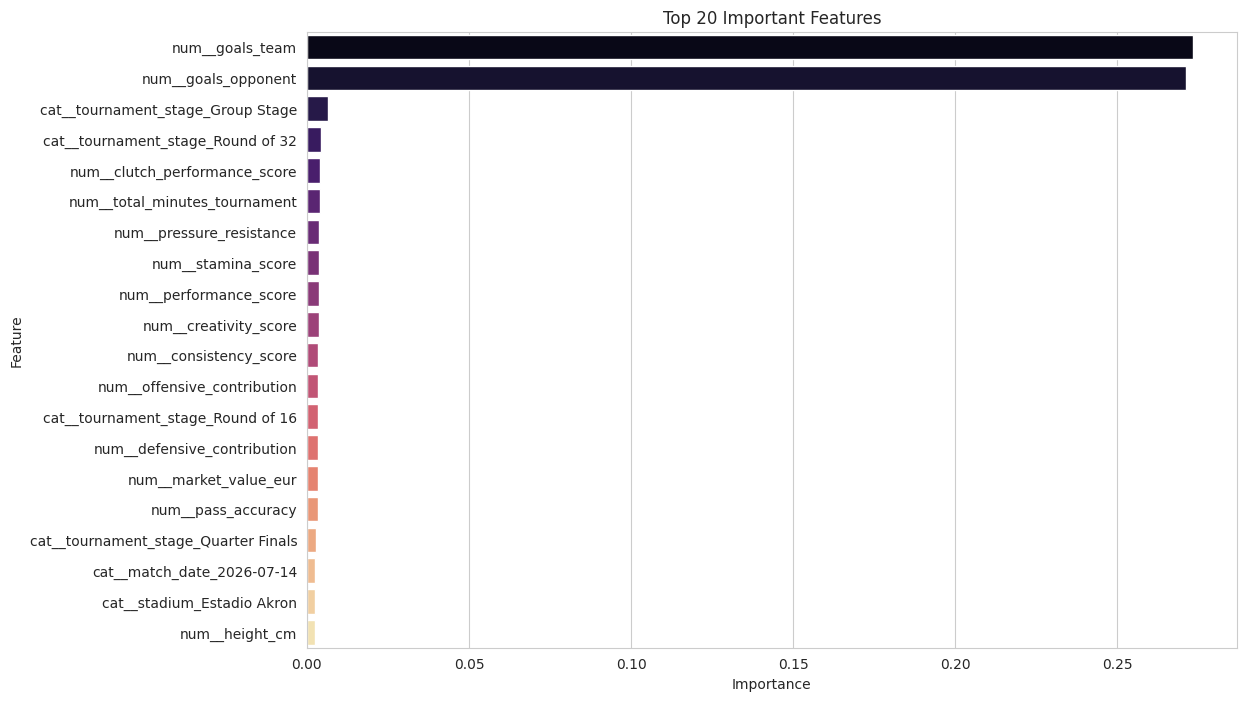


Top Important Features
                                  Feature  Importance
5                         num__goals_team    0.273246
6                     num__goals_opponent    0.271102
417     cat__tournament_stage_Group Stage    0.006355
420     cat__tournament_stage_Round of 32    0.004411
55          num__clutch_performance_score    0.004166
58          num__total_minutes_tournament    0.004015
52               num__pressure_resistance    0.003786
46                     num__stamina_score    0.003759
48                 num__performance_score    0.003705
53                  num__creativity_score    0.003653
54                 num__consistency_score    0.003572
49            num__offensive_contribution    0.003515
419     cat__tournament_stage_Round of 16    0.003496
50            num__defensive_contribution    0.003476
4                   num__market_value_eur    0.003364
17                     num__pass_accuracy    0.003318
418  cat__tournament_stage_Quarter Finals    0.002734
318 

In [18]:
print("Shape:", df.shape)

# ============================================================
# REMOVE ID COLUMNS
# ============================================================

drop_cols = [
    'player_id',
    'match_id',
    'player_name'
]

df = df.drop(columns=drop_cols, errors='ignore')

# ============================================================
# TARGET COLUMN
# ============================================================

TARGET = "match_result"

# ============================================================
# FEATURES & TARGET
# ============================================================

X = df.drop(TARGET, axis=1)
y = df[TARGET]

# ============================================================
# LABEL ENCODE TARGET
# ============================================================

target_encoder = LabelEncoder()
y_encoded = target_encoder.fit_transform(y)

print("\nTarget Classes:")
print(dict(zip(
    target_encoder.classes_,
    range(len(target_encoder.classes_))
)))

# ============================================================
# TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("\nTrain Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

# ============================================================
# IDENTIFY COLUMN TYPES
# ============================================================

numeric_features = X_train.select_dtypes(
    include=['int64','float64']
).columns

categorical_features = X_train.select_dtypes(
    include=['object']
).columns

print("\nNumeric Features:", len(numeric_features))
print("Categorical Features:", len(categorical_features))

# ============================================================
# PREPROCESSING PIPELINE
# ============================================================

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

# ============================================================
# MODELS
# ============================================================

models = {
    "Logistic Regression":
        LogisticRegression(max_iter=5000),

    "Decision Tree":
        DecisionTreeClassifier(random_state=42),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=300,
            random_state=42
        ),

    "Gradient Boosting":
        GradientBoostingClassifier(
            random_state=42
        )
}

# ============================================================
# TRAIN & EVALUATE
# ============================================================

results = []

for model_name, model in models.items():

    print("\n" + "="*60)
    print(model_name)
    print("="*60)

    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

    # TRAIN ONLY ON TRAIN DATA
    pipe.fit(X_train, y_train)

    # PREDICTIONS
    y_pred = pipe.predict(X_test)

    # ACCURACY
    acc = accuracy_score(y_test, y_pred)

    results.append([model_name, acc])

    print(f"\nAccuracy: {acc:.4f}")

    print("\nClassification Report:")
    print(
        classification_report(
            y_test,
            y_pred,
            target_names=target_encoder.classes_
        )
    )

    # CONFUSION MATRIX
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6,5))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=target_encoder.classes_,
        yticklabels=target_encoder.classes_
    )

    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# ============================================================
# ACCURACY COMPARISON
# ============================================================

results_df = pd.DataFrame(
    results,
    columns=["Model","Accuracy"]
)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

print("\nModel Comparison")
print(results_df)

plt.figure(figsize=(10,5))
sns.barplot(
    data=results_df,
    x='Accuracy',
    y='Model',
    palette='viridis'
)

plt.title("Model Accuracy Comparison")
plt.show()

# ============================================================
# BEST MODEL
# ============================================================

best_model_name = results_df.iloc[0]['Model']

print("\nBest Model:", best_model_name)

best_model = models[best_model_name]

best_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', best_model)
])

best_pipeline.fit(X_train, y_train)

# ============================================================
# ROC CURVE (MULTICLASS)
# ============================================================

if hasattr(best_pipeline.named_steps['classifier'],
           "predict_proba"):

    y_score = best_pipeline.predict_proba(X_test)

    n_classes = len(np.unique(y_encoded))

    y_test_bin = label_binarize(
        y_test,
        classes=np.arange(n_classes)
    )

    plt.figure(figsize=(10,8))

    for i in range(n_classes):

        fpr, tpr, _ = roc_curve(
            y_test_bin[:, i],
            y_score[:, i]
        )

        roc_auc = auc(fpr, tpr)

        plt.plot(
            fpr,
            tpr,
            lw=2,
            label=f"{target_encoder.classes_[i]} "
                  f"(AUC={roc_auc:.3f})"
        )

    plt.plot(
        [0,1],
        [0,1],
        linestyle='--'
    )

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Multiclass ROC Curve")
    plt.legend()
    plt.grid(True)
    plt.show()

# ============================================================
# FEATURE IMPORTANCE
# (Random Forest Only)
# ============================================================

rf_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier',
        RandomForestClassifier(
            n_estimators=300,
            random_state=42
        ))
])

rf_pipe.fit(X_train, y_train)

feature_names = (
    rf_pipe.named_steps['preprocessor']
    .get_feature_names_out()
)

importance = (
    rf_pipe.named_steps['classifier']
    .feature_importances_
)

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
).head(20)

plt.figure(figsize=(12,8))

sns.barplot(
    data=importance_df,
    x='Importance',
    y='Feature',
    palette='magma'
)

plt.title("Top 20 Important Features")
plt.show()

print("\nTop Important Features")
print(importance_df.head(20))

# ============================================================
# END
# ============================================================

print("\nMachine Learning Pipeline Completed Successfully")

## Thank you...pls upvote!!!!!!!!!!!!!!!!!!